Creates P(delta | prev_bass, curr_soprano)

In [1]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

#move to home directory
os.chdir('..')

In [2]:
def csv_to_tracks(file_path):
    """
    Reads a 4-column CSV and returns four 1D numpy arrays.
    
    Args:
        file_path (str): Path to the .csv file.
        
    Returns:
        tuple: (arr1, arr2, arr3, arr4) as 1D numpy arrays.
    """
    
    # unpack=True turns columns into individual arrays
    # skip_header=1 ignores the first row of text
    # delimiter=',' ensures we parse CSV format correctly
    S, A, T, B = np.genfromtxt(
        file_path, 
        delimiter=',', 
        unpack=True, 
        skip_header=1
    )
    
    return S, A, T, B


# path = Path('jsb_chorales', 'train', 'chorale_000.csv')
# S, A, T, B = csv_to_tracks(path)


In [3]:
def delta_2_index(delta, num_semitones=4):
    """
    turns sometimes negative valued deltas into a consistent index, including processing rests
    [ 0.  1.  2.  3.  4. -4. -3. -2. -1.]
    if non-negative, index is delta
    if negative, index is  2 x (number of semitones) + 1 + delta (e.g. -1 -> 8, -4 -> 5)
    if rest, maps to 2 x (number of semitones) + 1
    arguments: takes in an integer delta (-num_semintones <= delta <= num_semitones) unless it's a rest
    returns: the index
    """

    if num_semitones >= delta >= 0:
        return int(delta)
    elif -1*num_semitones <= delta < 0:
        return int((2*num_semitones+1)+delta)
    else:
        print(f'd2i: delta = {delta}, marking as a rest') #I'm assuming this is unlikely
        return int((2*num_semitones+1))


def index_2_delta(index, num_semitones=4):
    """turns indices back into deltas as described in delta_2_index"""

    if index <= num_semitones: #if delta is positive
        return int(index)
    elif num_semitones < index < 2*num_semitones+1: #if delta is negative 
        return int(index - (2*num_semitones+1))
    else:
        print(f'i2d: index = {index}, marking as a rest')
        return int(100) #placeholder for rest

# num_semitones = 4
# L = np.zeros(num_semitones*2 + 2)
# for i in range(len(L)):
#     L[i] = index_2_delta(i)
    
# print(L)

# for i in range(len(L)):
#     L[i] = delta_2_index(L[i])

# print(L)

In [49]:
# iterate through a chorale csv
# compute delta from curr_soprano - prev_soprano
# get the previous bass note
# get the current soprano note
# add 1 to the lookup table at index (prev_bass, curr_soprano, delta)
# normalize the lookup table.

# Directory containing the CSV files
train_dir = os.path.join('jsb_chorales', 'train')

def get_delta_3d_lookup(train_dir, num_semitones=4):
    #returns the log probability matrix of P(delta | soprano_{n-1}, bass_n)
    #index by (bass, prev_sporano, delta)
    # lookup_table = np.ones((128, 128, 2*num_semitones+2)) * 1/1000
    lookup_table = np.ones((128, 128, 2*num_semitones+2)) * 0


    songs = glob.glob('*.csv', root_dir=train_dir)
    songs = [s for s in songs if not 'd' in s] #remove all strings with 'd' in them (filters out chord csv)

    # Iterate through every .csv in the train directory
    for songname in songs:
        # You can now use `csv_path` for each CSV file
        csv_path = os.path.join(train_dir, songname)
        
        print(f"Processing {csv_path}")
        S, A, T, B = csv_to_tracks(csv_path)
        
        # Combine into array of tuples [(S, A, T, B)]
        SATB_tuples = list(zip(S, A, T, B))
        for i in range(1, len(SATB_tuples)):
            #get current tuple
            s, _, _, b = SATB_tuples[i]

            # get previous soprano note
            prev_s = SATB_tuples[i-1][0]

            # get delta
            delta = s - prev_s

            # add 1 to the lookup table at index (bass, prev_soprano, delta)
            lookup_table[int(b), int(prev_s), delta_2_index(delta)] += 1
            
        return lookup_table

        # normalize the lookup table (for each delta)
        # for i in range(lookup_table.shape[2]):
            # print(i)
            # lookup_table[:, :, i] = lookup_table[:, :, i] / np.sum(lookup_table[:, :, i])
            
        # return np.log(lookup_table)

Processing jsb_chorales\train\chorale_000.csv
d2i: delta = -7.0, marking as a rest
d2i: delta = 5.0, marking as a rest
shape: (163840,)
max: 25.0
min: 0.0
mean: 0.001165771484375
first, second, and third quartiles: [0. 0. 0.]
(128, 128, 10)


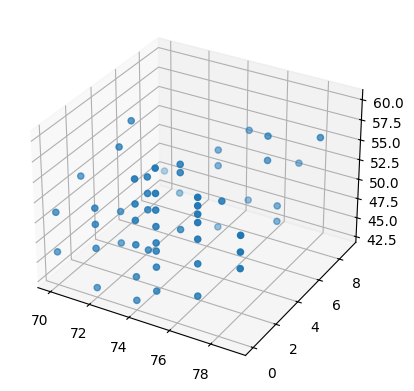

In [ ]:
lookup_table = get_delta_3d_lookup(train_dir)
lookup_table_arr = np.ndarray.flatten(lookup_table)
print(f"shape: {np.shape(lookup_table_arr)}")
print(f"max: {np.max(lookup_table_arr)}")
print(f"min: {np.min(lookup_table_arr)}")
print(f"mean: {np.mean(lookup_table_arr)}")
print(f"first, second, and third quartiles: {np.percentile(lookup_table_arr, [25, 50, 75])}")
# print(f"nonzero entries: {np.sum(lookup_table_arr[lookup_table_arr > 0.001])}")
# print(f"zero entries: {np.sum(lookup_table_arr[lookup_table_arr <= 0.001])}")
print(np.shape(lookup_table))
# https://stackoverflow.com/questions/12414619/creating-a-3d-plot-from-a-3d-numpy-array

# from mpl_toolkits.mplot3d import Axes3D
z, x, y = lookup_table.nonzero()
ax = plt.subplot(111, projection='3d')
ax.scatter(y, x, z)
plt.show()


# plt.plot(lookup_table_arr)
# info = plt.boxplot(np.transpose(lookup_table_arr))
# plt.hist(np.transpose(lookup_table_arr))

In [6]:
for i in range(10):
    print(np.sum(lookup_table[:, :, i]))


-112930.20236760407
-113148.3348241708
-113120.29450654268
-113169.75373606401
-113176.66249084333
-113176.66249084333
-113162.8449812847
-113126.22326472233
-113161.45968617416
-113162.8449812847


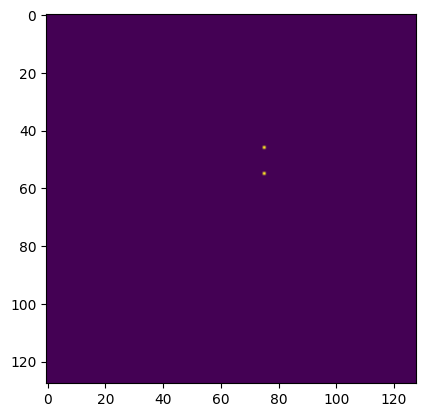

In [7]:
plt.imshow(lookup_table[:, :, 8])
plt.show()

In [8]:
print(np.size(np.nonzero(lookup_table)))

491520
